In [1]:
!nvidia-smi
import sys
conda_env = sys.path[1]
del sys.path[1]
import os
home = os.path.expanduser("~/")
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path

Tue Oct 28 19:17:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:03:00.0 Off |                    0 |
| N/A   33C    P0             72W /  400W |       1MiB /  40960MiB |      7%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

['',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '/usr/local/lib/python3.12/dist-packages',
 '__editable__.flax-0.10.6.finder.__path_hook__',
 '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__',
 '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__',
 '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__',
 '/opt/pip/src',
 '/usr/lib/python3/dist-packages',
 '/global/homes/l/linusu//gigalens/src',
 '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages']

In [2]:
from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear
from corner import corner

import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
tfd = tfp.distributions

2025-10-28 19:17:47.340368: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761704267.351411 1255102 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761704267.355882 1255102 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761704267.367639 1255102 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761704267.367651 1255102 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761704267.367653 1255102 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/global/homes/l/linusu//gigalens/src/gigalens/jax/inference.py:28: UserWarning: jax.distributed.initialize() was not called. For multinode, please call it before running any JAX functions.
  warnings.warn('jax.distributed.initialize() was not called. For multinode, please call it before running any JAX functions.')


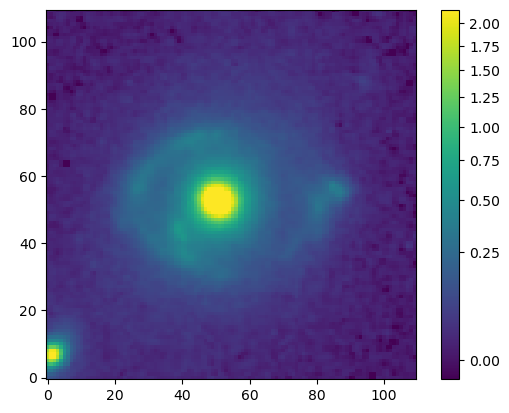

In [3]:
from astropy.io import fits
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt
import numpy as np

data94 = fits.open("final_94_drz.fits")
image94 = data94[1].data
exp_time = data94[0].header["EXPTIME"]
data94.close()
#image94[image94<0] = 0
image_size = 110
lens_x=1227
lens_y=1070
system = image94[(int)(lens_y-image_size/2):(int)(lens_y+image_size/2),(int)(lens_x-image_size/2):(int)(lens_x+image_size/2)]

norm = simple_norm(system, "sqrt", percent=99.)
plt.imshow(system, norm=norm, cmap="viridis", origin='lower')
plt.colorbar()

epsfdata = fits.open("psf94.fits")
epsf = epsfdata[0].data
epsfdata.close()

In [4]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.5), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(-0.3, 0.15),
                center_y=tfd.Normal(-0.1, 0.15),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.15), gamma2=tfd.Normal(0, 0.15))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(24, 28),
                e1=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                center_x=tfd.Normal(-3.4, 0.25),
                center_y=tfd.Normal(-3.1, 0.25),
                Ie=tfd.LogNormal(jnp.log(100), 0.5),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(2, 6),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(-0.3, 0.05),
                center_y=tfd.Normal(-0.1, 0.05),
                Ie=tfd.LogNormal(jnp.log(100), 0.5),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(4, 8),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(-0.3, 0.05),
                center_y=tfd.Normal(-0.1, 0.05),
                Ie=tfd.LogNormal(jnp.log(30), 0.5),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(-0.2, 0.25),
                center_y=tfd.Normal(-0.2, 0.25),
                Ie=tfd.LogNormal(jnp.log(20.0), 0.5),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0.2, 0.25),
                center_y=tfd.Normal(0, 0.25),
                Ie=tfd.LogNormal(jnp.log(30.0), 0.5), #need to increase slightly more somehow I think
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

In [5]:
kernel = np.array(epsf).astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=110, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False),sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False), sersic.SersicEllipse(use_lstsq=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = system
background_rms = 0.007616264 #background_rms from photutils.background
prob_model = ForwardProbModel(prior, observed_img, background_rms=background_rms, exp_time=exp_time)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [6]:
schedule_fn = optax.polynomial_schedule(init_value=-0.01, end_value=-0.003, 
                                      power=0.1, transition_steps=1000)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
map_estimate = model_seq.MAP_multi(opt, seed=0, num_steps=1000)

2025-10-28 19:18:37.825564: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng35{k2=1,k5=3,k14=2} for conv %cudnn-conv = (f32[125,1,220,220]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.61, %constant.9371), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_name="jit(run_map)/jit(main)/jit(shmap_body)/while/body/jit(loss)/jvp(jit(log_prob))/jit(simulate)/conv_general_dilated" source_file="/global/homes/l/linusu//gigalens/src/gigalens/jax/simulator.py" source_line=80}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-10-28 19:18:39.458038: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.632610994s
Trying algorithm eng35{k2=1,k5=3,k14=2} for conv %cudnn

In [7]:
lps = prob_model.log_prob(LensSimulator(phys_model, sim_config, bs=500), map_estimate[0])[0]
best = map_estimate[jnp.argmax(lps)][jnp.newaxis,:]

2025-10-28 19:20:39.861469: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=3,k3=0} for conv %cudnn-conv = (f32[500,1,220,220]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.96, %constant.7837), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_name="jit(log_prob)/jit(main)/jit(simulate)/conv_general_dilated" source_file="/global/homes/l/linusu//gigalens/src/gigalens/jax/simulator.py" source_line=80}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-10-28 19:20:39.941694: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.080335413s
Trying algorithm eng28{k2=3,k3=0} for conv %cudnn-conv = (f32[500,1,220,220]{3,2,1,0}, u8[0]{0}) custom-call(%bitcas

[[{'theta_E': Array([[1.46685]], dtype=float32), 'gamma': Array([[1.901958]], dtype=float32), 'e2': Array([[0.03663935]], dtype=float32), 'e1': Array([[0.01279562]], dtype=float32), 'center_y': Array([[-0.12525642]], dtype=float32), 'center_x': Array([[-0.26696676]], dtype=float32)}, {'gamma2': Array([[-0.00973747]], dtype=float32), 'gamma1': Array([[0.15214504]], dtype=float32)}], [{'n_sersic': Array([[26.625519]], dtype=float32), 'e2': Array([[0.22947717]], dtype=float32), 'e1': Array([[-0.22084123]], dtype=float32), 'center_y': Array([[-3.0867512]], dtype=float32), 'center_x': Array([[-3.4392264]], dtype=float32), 'R_sersic': Array([[0.3465902]], dtype=float32), 'Ie': Array([[34.571236]], dtype=float32)}, {'n_sersic': Array([[5.412772]], dtype=float32), 'e2': Array([[-0.11680444]], dtype=float32), 'e1': Array([[0.03480914]], dtype=float32), 'center_y': Array([[-0.10498551]], dtype=float32), 'center_x': Array([[-0.27080953]], dtype=float32), 'R_sersic': Array([[0.6093524]], dtype=flo

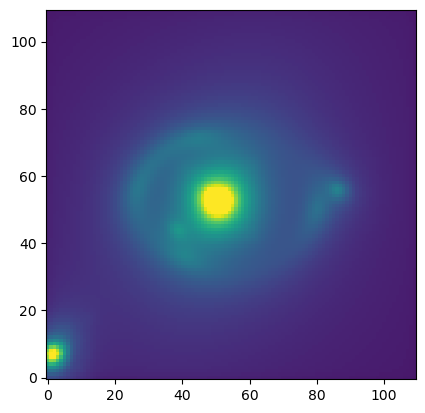

In [8]:
physical = prob_model.bij.forward(list(best.T))
print(physical)
simulated = lens_sim.simulate(physical)
plt.imshow(simulated, norm=norm, cmap="viridis", origin='lower')

In [9]:
schedule_fn = optax.polynomial_schedule(init_value=-1e-6, end_value=-3e-3, 
                                      power=2, transition_steps=300)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
qz, loss_hist = model_seq.SVI_multi(best, opt, n_vi=1000, num_steps=1500)

2025-10-28 19:22:07.173753: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-28 19:22:07.173786: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-28 19:22:11.535046: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng35{k2=1,k5=3,k14=2} for conv %cudnn-conv = (f32[250,1,220,220]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.70, %constant.10125), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_name="jit(get_update)/jit

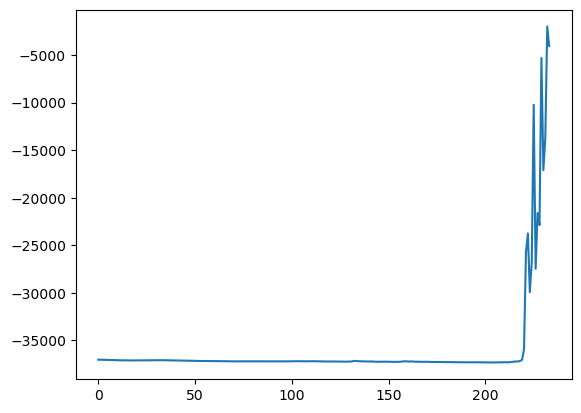

In [10]:
plt.plot(loss_hist)

In [14]:
L_32 = np.array(qz.scale_tril, dtype=np.float32)
L_64 = np.array(qz.scale_tril, dtype=np.float64)
L_128 = np.array(qz.scale_tril, dtype=np.float128)
print("Float32 Eigenvalues: ", np.linalg.eig(L_32@L_32.T)[0])
print("Float64 Eigenvalues: ", np.linalg.eig(L_64@L_64.T)[0])
print("Float128 Eigenvalues: ", np.linalg.eig(np.array(L_128@L_128.T, dtype=np.float64))[0])

Float32 Eigenvalues:  [ 6.7688614e-02  1.7035909e-02  5.7737660e-03  2.8401578e-03
  1.4849430e-03  9.1606588e-04  7.8928471e-04  5.4468220e-04
  5.0729112e-04  2.5397175e-04  1.9532417e-04  1.4527896e-04
  7.5220007e-05  5.3452179e-05  4.0165844e-05  3.4855817e-05
  2.3646104e-05  1.5246349e-05  1.3460544e-05  1.1177537e-05
  7.5940902e-06  5.0463796e-06  3.7080183e-06  3.4370105e-06
  2.6332280e-06  2.1739095e-06  1.6744692e-06  8.6508004e-07
  6.5713903e-07  4.9244159e-07  2.5986310e-07  1.5876064e-07
  1.1168668e-07  8.1267537e-08  3.6393974e-08  3.0841193e-08
  1.5008640e-08  5.8215908e-09  2.0823605e-09  3.1640168e-10
  4.9679043e-13 -5.7547357e-14 -6.8937255e-13]
Float64 Eigenvalues:  [ 6.76886146e-02  1.70359096e-02  5.77376586e-03  2.84015782e-03
  1.48494295e-03  9.16066000e-04  7.89284692e-04  5.44682111e-04
  5.07291107e-04  2.53971710e-04  1.95324176e-04  1.45278953e-04
  7.52200039e-05  5.34521345e-05  4.01658392e-05  3.48558120e-05
  2.36461023e-05  1.52463412e-05  1.346

In [ ]:
samples = model_seq.HMC_multi(qz, num_burnin_steps=750, num_results=750)

In [ ]:
rhat= tfp.mcmc.potential_scale_reduction(jnp.transpose(samples, (1,2,0,3)), independent_chain_ndims=2)
ess = tfp.mcmc.effective_sample_size(jnp.transpose(samples, (1,2,0,3)), cross_chain_dims=[1,2])
numParams = len(rhat)
for i in range(0,numParams):
    print(i, rhat[i], ess[i], rhat[i]<1.01)

In [ ]:
smp = jnp.transpose(samples, (1, 2, 0, 3)).reshape((-1, numParams))
smp_physical = prob_model.bij.forward(list(smp.T))

def get_corner_samples(physical, key):
    """
    Key tells you lens_mass (1), lens_light (2), or source_light (3)
    """
    return_list = []

    if key == 1:
        for i in physical[0][0].keys():
            return_list.append(physical[0][0][i])
        for j in physical[0][1].keys():
            return_list.append(physical[0][1][j])

    if key == 2:
        for i in physical[1][0].keys():
            return_list.append(physical[1][0][i])

    if key == 3:
        for i in physical[2][0].keys():
            return_list.append(physical[2][0][i])
            
    return np.stack(return_list).T

mass_samps = get_corner_samples(smp_physical, 1)
median_params = [
    [
        {key: np.median(value) for key, value in d.items()}
        for d in list_of_dicts
    ]
    for list_of_dicts in smp_physical
]
import pprint
pprint.pprint(median_params)

In [ ]:
plt.style.use('default')

labels=[r'$\theta_E$', 
        r'$\gamma$', 
        r'$\epsilon_1$', 
        r'$\epsilon_2$', 
        r'$x$', r'$y$', 
        r'$\gamma_{1,ext}$', 
        r'$\gamma_{2,ext}$']

fig = corner(mass_samps, show_titles=True, title_fmt='.3f', labels=labels)
_ = fig.suptitle("Lens Parameters")

In [ ]:
simulated = lens_sim.simulate(median_params)
residual = simulated - jnp.array(system, dtype=jnp.float32)
err_map = np.sqrt(background_rms**2 + simulated/exp_time)
norm_residual = residual/err_map
print(np.mean(np.square(norm_residual)))

fig, ax = plt.subplots(1,4, figsize=(25,4))
image_sys = ax[0].imshow(system, norm=norm, cmap="viridis", origin='lower')
image_sim = ax[1].imshow(simulated, norm=norm, cmap="viridis", origin='lower')
image_res = ax[2].imshow(residual, cmap="coolwarm", origin='lower')
image_nres = ax[3].imshow(norm_residual, cmap="coolwarm", origin='lower')
ax[0].set_title("Observed System")
ax[1].set_title("Simulated System")
ax[2].set_title("Residuals")
ax[3].set_title("Normalized Residuals")
plt.colorbar(image_res)
plt.colorbar(image_nres)
plt.show()

In [ ]:
phys_model2 = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False), sersic.SersicEllipse(use_lstsq=False), sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim2 = LensSimulator(phys_model2, sim_config, bs=1)
obj1 = median_params[:]
obj1[-1] = [median_params[-1][0]]
simulatedobj1 = lens_sim2.simulate(obj1)
obj2 = median_params[:]
obj2[-1] = [median_params[-1][1]]
simulatedobj2 = lens_sim2.simulate(obj2)
fig, ax = plt.subplots(1,2, figsize=(10,4))
simobj1 = ax[0].imshow(simulatedobj1, norm=norm, cmap="viridis", origin='lower')
simobj2 = ax[1].imshow(simulatedobj2, norm=norm, cmap="viridis", origin='lower')
ax[0].set_title("Simulated System - Object 1")
ax[1].set_title("Simulated System - Object 2")
plt.show()